# 05 — Explainability

SHAP analysis for both Lead Scoring and Yield Prediction models.  
Global feature importance · beeswarm plots · waterfall for individual applicants.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from src.utils import set_seeds, SYNTHETIC_DIR, OUTPUT_DIR
import src.lead_model as lm
import src.yield_model as ym

set_seeds()

df = pd.read_csv(SYNTHETIC_DIR / 'applicants.csv')
admits = df[df['admitted'] == 1]

lead_art  = lm.load()
yield_art = ym.load()
print('Models loaded.')

Models loaded.


## Lead Model — Global SHAP Summary

C:\Users\jeged\AppData\Local\Temp\ipykernel_500512\3942417345.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


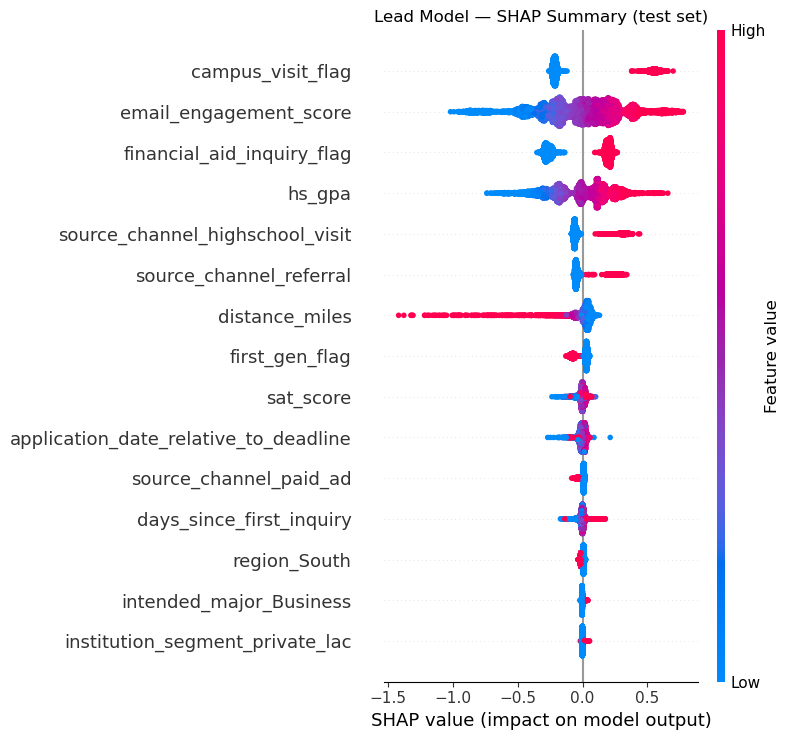

In [2]:
# Use test set for SHAP (representative, unseen)
X_lead_test = lead_art['X_test']
lead_shap = lead_art['explainer'].shap_values(X_lead_test)

fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(
    lead_shap,
    X_lead_test,
    feature_names=lead_art['feature_names'],
    max_display=15,
    show=False,
)
plt.title('Lead Model — SHAP Summary (test set)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lead_shap_summary.png', bbox_inches='tight')
plt.show()

## Lead Model — Global Feature Importance (mean |SHAP|)

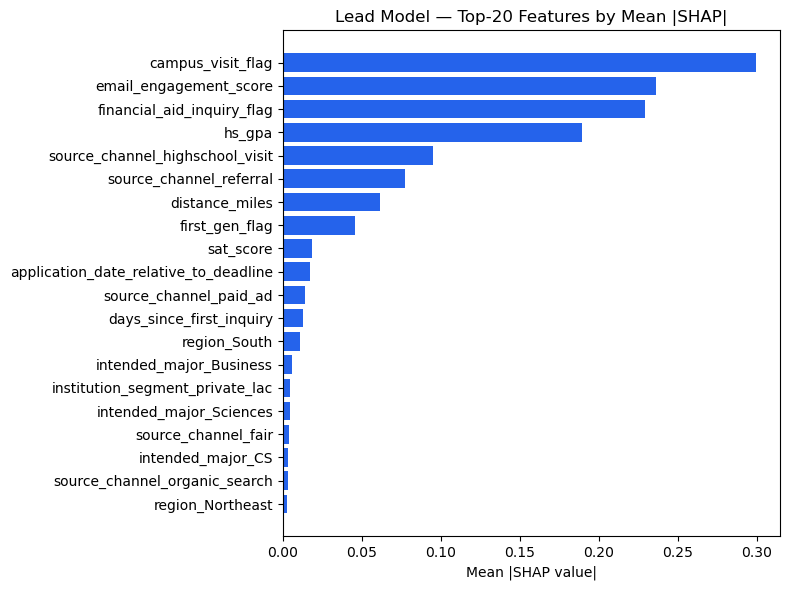


Top-10:


'                              feature  mean_abs_shap\n                    campus_visit_flag       0.299877\n               email_engagement_score       0.236460\n           financial_aid_inquiry_flag       0.229197\n                               hs_gpa       0.189357\n      source_channel_highschool_visit       0.095368\n              source_channel_referral       0.077539\n                       distance_miles       0.061727\n                       first_gen_flag       0.045599\n                            sat_score       0.018353\napplication_date_relative_to_deadline       0.017454'

In [3]:
mean_abs_shap = np.abs(lead_shap).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': lead_art['feature_names'],
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['feature'][::-1], importance_df['mean_abs_shap'][::-1], color='#2563eb')
ax.set(title='Lead Model — Top-20 Features by Mean |SHAP|', xlabel='Mean |SHAP value|')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lead_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop-10:')
importance_df.head(10).to_string(index=False)

## Lead Model — Waterfall for individual applicants

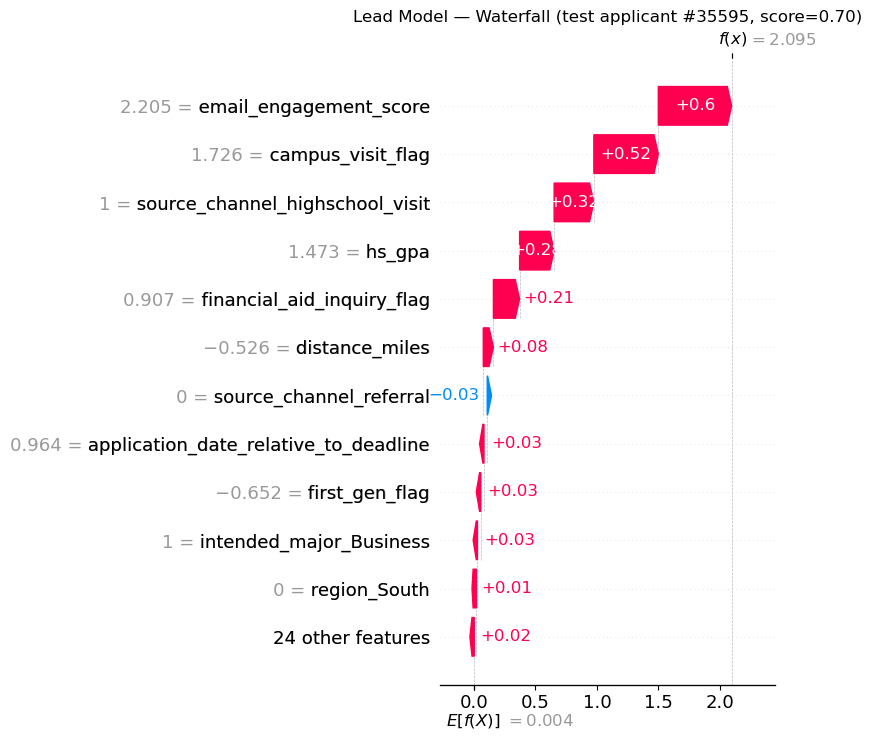

In [4]:
# Highest-score lead in test set
test_idx = lead_art['test_idx']
test_df  = df.iloc[test_idx].copy().reset_index(drop=True)
X_lead_test_raw = lead_art['preprocessor'].transform(test_df[lm.FEATURE_COLS])
lead_probs = lead_art['xgb'].predict_proba(X_lead_test_raw)[:, 1]
top_i = int(np.argmax(lead_probs))

explainer = lead_art['explainer']
exp = shap.Explanation(
    values=lead_shap[top_i],
    base_values=explainer.expected_value,
    data=X_lead_test[top_i],
    feature_names=lead_art['feature_names'],
)

fig, ax = plt.subplots(figsize=(9, 5))
shap.waterfall_plot(exp, max_display=12, show=False)
plt.title(f'Lead Model — Waterfall (test applicant #{test_idx[top_i]}, score={lead_probs[top_i]:.2f})')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lead_waterfall_sample.png', bbox_inches='tight')
plt.show()

## Yield Model — Global SHAP Summary

C:\Users\jeged\AppData\Local\Temp\ipykernel_500512\1344400900.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


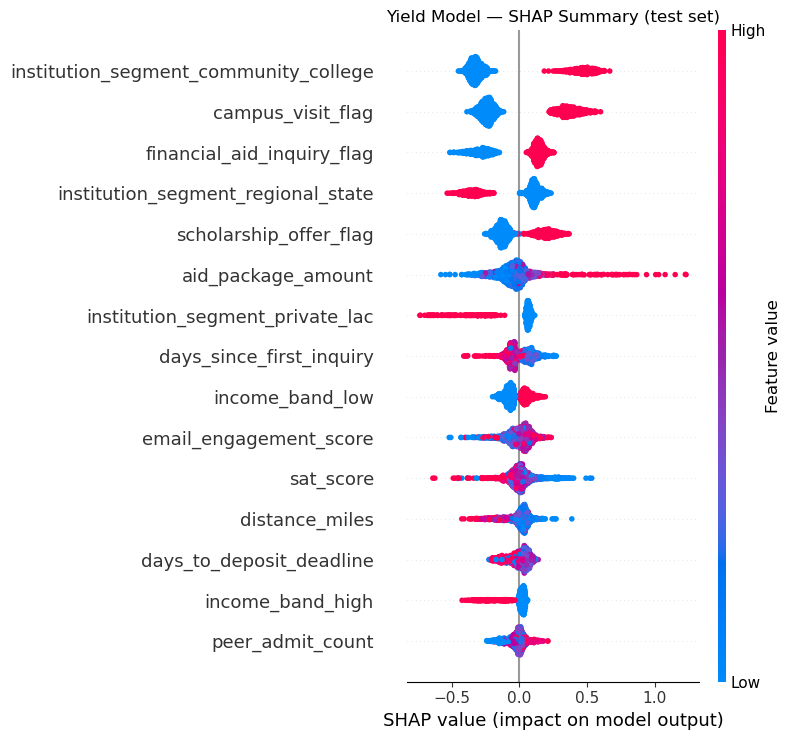

In [5]:
X_yield_test = yield_art['X_test']
yield_shap = yield_art['explainer'].shap_values(X_yield_test)

fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(
    yield_shap,
    X_yield_test,
    feature_names=yield_art['feature_names'],
    max_display=15,
    show=False,
)
plt.title('Yield Model — SHAP Summary (test set)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'yield_shap_summary.png', bbox_inches='tight')
plt.show()

## Yield Model — Feature Importance

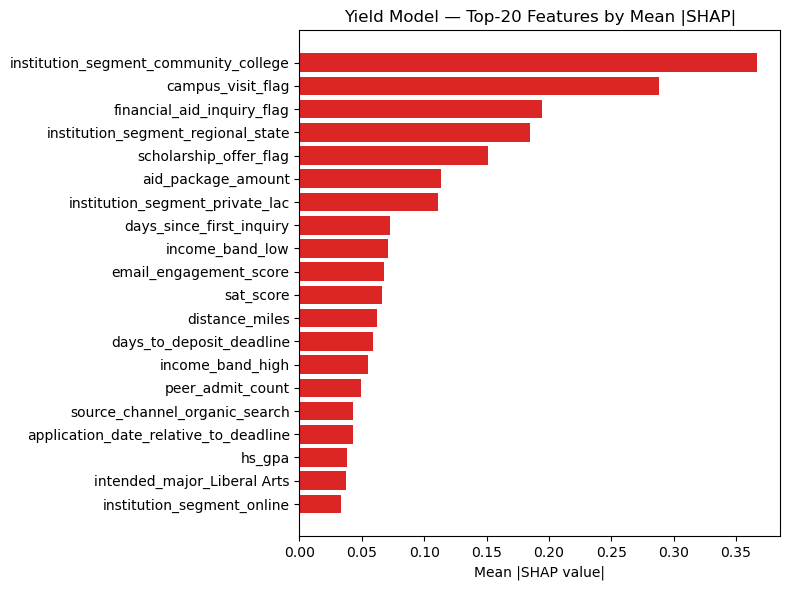

In [6]:
mean_abs_yield = np.abs(yield_shap).mean(axis=0)
yield_imp = pd.DataFrame({
    'feature': yield_art['feature_names'],
    'mean_abs_shap': mean_abs_yield
}).sort_values('mean_abs_shap', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(yield_imp['feature'][::-1], yield_imp['mean_abs_shap'][::-1], color='#dc2626')
ax.set(title='Yield Model — Top-20 Features by Mean |SHAP|', xlabel='Mean |SHAP value|')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'yield_feature_importance.png', bbox_inches='tight')
plt.show()

## SHAP dependence: first_gen_flag effect on lead scores

The synthetic data has an intentional `-0.15` first_gen logit penalty.  
This cell confirms SHAP picks it up — verification before the bias audit notebook.

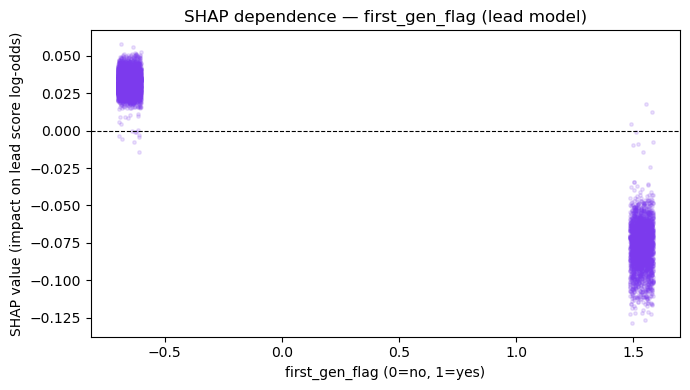

Mean SHAP for first_gen=0: nan
Mean SHAP for first_gen=1: nan
Penalty signal (1 vs 0)  : nan  (negative = lower lead score for first-gen)


C:\Users\jeged\AppData\Local\Temp\ipykernel_500512\1983943180.py:20: RuntimeWarning: Mean of empty slice.
  mean_0 = fg_shap[fg_vals == 0].mean()
C:\Users\jeged\anaconda3\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\jeged\AppData\Local\Temp\ipykernel_500512\1983943180.py:21: RuntimeWarning: Mean of empty slice.
  mean_1 = fg_shap[fg_vals == 1].mean()


In [7]:
# Find first_gen_flag index in feature_names (it's a numeric feature, direct position)
fn = lead_art['feature_names']
fg_idx = fn.index('first_gen_flag') if 'first_gen_flag' in fn else None

if fg_idx is not None:
    fg_vals   = X_lead_test[:, fg_idx]
    fg_shap   = lead_shap[:, fg_idx]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(fg_vals + np.random.uniform(-0.05, 0.05, len(fg_vals)),
               fg_shap, alpha=0.15, s=6, color='#7c3aed')
    ax.axhline(0, color='k', lw=0.8, linestyle='--')
    ax.set(title='SHAP dependence — first_gen_flag (lead model)',
           xlabel='first_gen_flag (0=no, 1=yes)',
           ylabel='SHAP value (impact on lead score log-odds)')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'lead_shap_firstgen.png', bbox_inches='tight')
    plt.show()

    mean_0 = fg_shap[fg_vals == 0].mean()
    mean_1 = fg_shap[fg_vals == 1].mean()
    print(f'Mean SHAP for first_gen=0: {mean_0:.4f}')
    print(f'Mean SHAP for first_gen=1: {mean_1:.4f}')
    print(f'Penalty signal (1 vs 0)  : {mean_1 - mean_0:.4f}  (negative = lower lead score for first-gen)')
else:
    print('first_gen_flag not found in feature_names:', fn)

## Cross-model comparison: shared top features

In [8]:
lead_top = set(importance_df.head(10)['feature'])
yield_top = set(yield_imp.head(10)['feature'])

print('Top-10 lead features :', sorted(lead_top))
print('Top-10 yield features:', sorted(yield_top))
print('Overlap              :', sorted(lead_top & yield_top))

Top-10 lead features : ['application_date_relative_to_deadline', 'campus_visit_flag', 'distance_miles', 'email_engagement_score', 'financial_aid_inquiry_flag', 'first_gen_flag', 'hs_gpa', 'sat_score', 'source_channel_highschool_visit', 'source_channel_referral']
Top-10 yield features: ['aid_package_amount', 'campus_visit_flag', 'days_since_first_inquiry', 'email_engagement_score', 'financial_aid_inquiry_flag', 'income_band_low', 'institution_segment_community_college', 'institution_segment_private_lac', 'institution_segment_regional_state', 'scholarship_offer_flag']
Overlap              : ['campus_visit_flag', 'email_engagement_score', 'financial_aid_inquiry_flag']
